In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py

%matplotlib inline

In [2]:
#load data
data = pd.read_excel("Concrete_Data.xls")

data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
#some data statistics
data.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [4]:
#count nulls for all variables
data.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
"Concrete compressive strength(MPa, megapascals)",0


In [5]:
#check for duplicates
data.duplicated().sum()

np.int64(25)

In [6]:
#some duplicated rows
data[data.duplicated()].head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171


In [7]:
#drop duplicates
data.drop_duplicates(inplace = True)

In [8]:
##check variable names
data.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

In [9]:
##randomize rows
data = data.sample(frac = 1, random_state = 42).reset_index(drop = True)
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,152.7,144.7,0.0,178.1,8.0,999.7,822.2,28,19.009543
1,122.6,183.9,0.0,203.5,0.0,958.2,800.1,28,24.290929
2,153.0,102.0,0.0,192.0,0.0,888.0,943.1,90,26.322815
3,480.0,0.0,0.0,192.0,0.0,936.2,712.2,7,34.569637
4,500.1,0.0,0.0,200.0,3.0,1124.4,613.2,28,44.133359


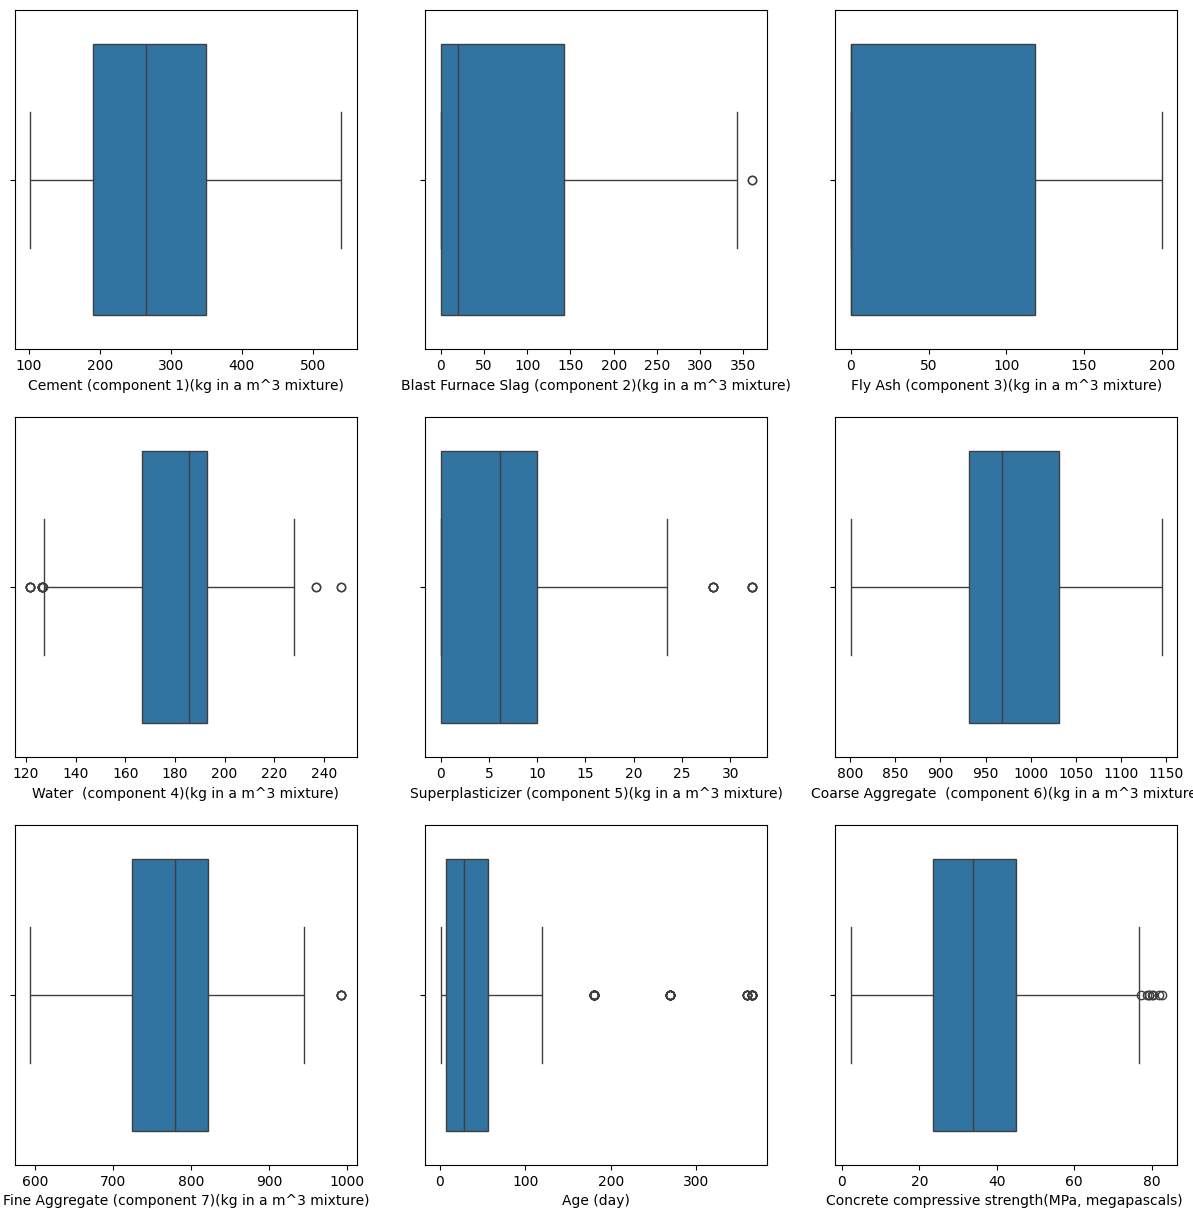

In [10]:
#plot grid
fig, ax = plt.subplots(3,3, figsize = (15,15))

columnas = np.array(data.columns).reshape(3,3)

#boxplot for each variable
for i in range(0,3):
  for j in range(0,3):
    sns.boxplot(data[columnas[i,j]], ax = ax[i,j], orient = "h")
    #ax[i,j].set_title(columnas[i,j])
plt.show()

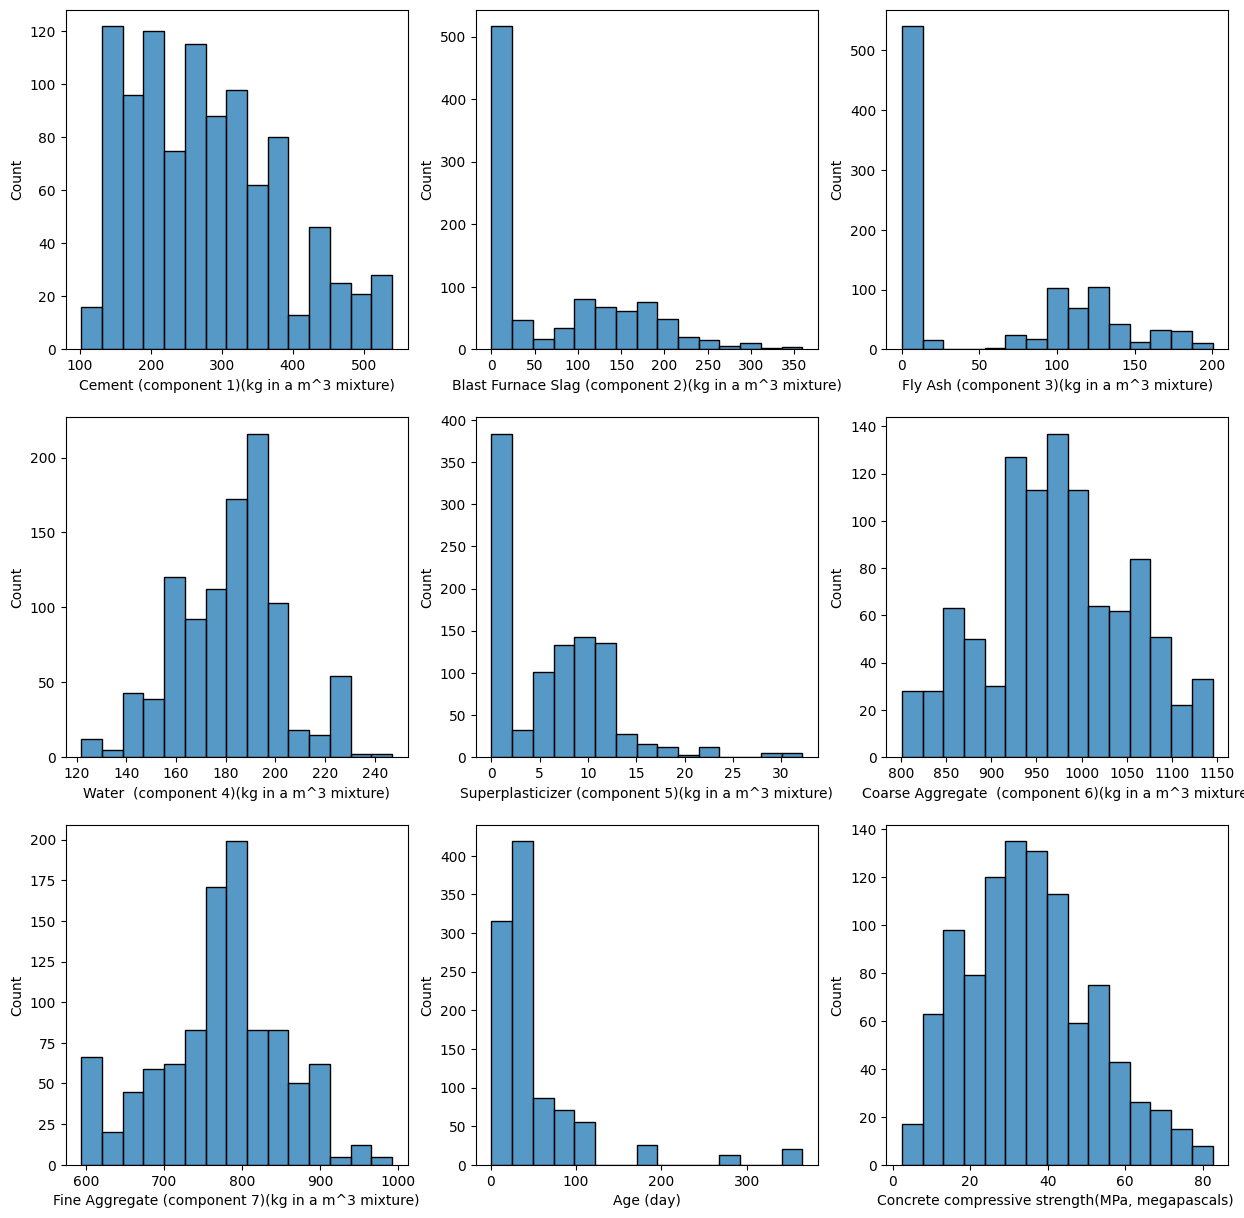

In [11]:
fig, axs = plt.subplots(3,3, figsize = (15,15))

columnas = np.array(data.columns).reshape(3,3)

#histogram for each variable
for i in range(0,3):
  for j in range(0,3):
    sns.histplot(data[columnas[i,j]], ax = axs[i,j], bins = 15)
    ax[i,j].set_title(columnas[i,j])
plt.show()

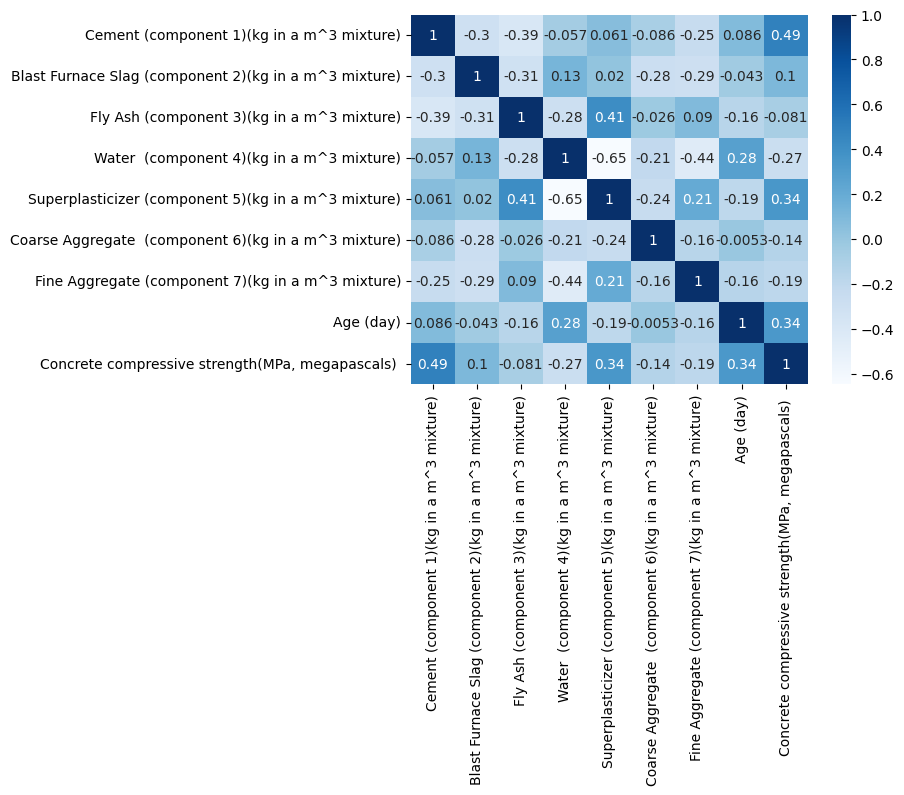

In [12]:
# correlation between variables
sns.heatmap(data.corr(), annot = True, cmap = "Blues")
plt.show()

#Hacemos ML

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

In [14]:
#target variable
target = data['Concrete compressive strength(MPa, megapascals) ']

#features used
x_features = data.drop('Concrete compressive strength(MPa, megapascals) ', axis = 1)

#standarization of features
x_features_scaled = StandardScaler().fit_transform(x_features)

x_train, x_test, y_train, y_test = train_test_split(x_features_scaled, target, test_size = 0.2, random_state = 42)

In [15]:
from sklearn.model_selection import GridSearchCV
#Applying random forest

#parameter grid
grid = {
    'n_estimators': [80, 90, 100],
    'max_depth': [10, 20, 30],
    "max_features": [0.1, 0.5, 1]
}

#create the model
modelo = RandomForestRegressor(random_state = 42)


# Configure GridSearchCV
grid_search = GridSearchCV(estimator=modelo, param_grid=grid, cv=3, scoring='neg_mean_absolute_error')

# Train the model using GridSearchCV
grid_search.fit(x_train, y_train)



GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': [0.1, 0.5, 1],
                         'n_estimators': [80, 90, 100]},
             scoring='neg_mean_absolute_error')

In [16]:
#predictions in training
y_train_pred = grid_search.predict(x_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)


#predictions in testing
y_test_pred = grid_search.predict(x_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE en training: ", mae_train)
print("MAE en testing: ", mae_test)
print("R2 en training: ", r2_train)
print("R2 en testing: ", r2_test)

MAE en training:  1.352431881954956
MAE en testing:  3.3537539727734593
R2 en training:  0.9841504531938255
R2 en testing:  0.9090868409560001


There seems to be a low overfitting. However, considering the target value range, a difference of approximately 2 megapascals in the mean absolute error between training and testing is not particularly significant. The R² score is consistently high, which aligns with the results obtained from the MAE evaluation.

In [22]:
#Applying GBR

#parameter grid
grid = {
    'n_estimators': [80, 90, 100],
    'max_depth': [10, 20, 30],
    "max_features": [0.1, 0.5, 0.7]
}

#create the model
modelo_gbr = GradientBoostingRegressor(random_state = 42)


# Configure GridSearchCV
grid_search_gbr = GridSearchCV(estimator=modelo_gbr, param_grid=grid, cv=3, scoring='neg_mean_absolute_error')

# Train the model using GridSearchCV
grid_search_gbr.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': [0.1, 0.5, 0.7],
                         'n_estimators': [80, 90, 100]},
             scoring='neg_mean_absolute_error')

In [23]:
#predictions in training
y_train_pred_gbr = grid_search_gbr.predict(x_train)
mae_train_gbr = mean_absolute_error(y_train, y_train_pred_gbr)
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)


#predictions in testing
y_test_pred_gbr = grid_search_gbr.predict(x_test)
mae_test_gbr = mean_absolute_error(y_test, y_test_pred_gbr)
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)

print("MAE en training: ", mae_train_gbr)
print("MAE en testing: ", mae_test_gbr)
print("R2 en training: ", r2_train_gbr)
print("R2 en testing: ", r2_test_gbr)

MAE en training:  0.07048690879177792
MAE en testing:  3.0661608653937713
R2 en training:  0.9972447595174274
R2 en testing:  0.9116556010284491


There is a bit more overfitting than in RF, and the increased gap between training and testing performance suggests it is not a better model for this dataset. Therefore, Random Forest appears to have better predictive performance.